## Statical Method Project 

- Made By :
1. Abdallah Waleed Kamal Mousa Salem      ID : 20230192 
2. Saif Sameh Fathy Elsawey               ID : 20230142
3. Abdelrahman Fathy Elbahrawey           ID : 20230176
4. Abdelrahman Ali Ghonemi Ayad           ID : 20230174

## Import Libraries 

Purpose: Import required Python libraries.
statistics: For calculating mean and other statistical metrics.
matplotlib.pyplot: For plotting graphs and visualizations.
scipy.stats: For statistical computations (correlation, regression, hypothesis testing, ANOVA, etc.).
numpy: For numerical operations (e.g., array manipulation)

In [6]:
import statistics
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np


## User Input

Purpose: Collect data from the user.
X and Y are lists of integers representing the independent and dependent variables, respectively.
Ensures that the length of X and Y are the same.
Checks if there are at least two elements in each list for statistical calculations.
If checks fail, it prints an error message.

In [7]:
X = list(map(int, input("Enter the values of X: ").split()))  # Values of X
Y = list(map(float, input("Enter the values of Y: ").split()))  # Values of Y

## Mean Calculation 

Purpose: Compute the mean of X and Y using statistics.mean().
Output: Prints the calculated means of X and Y.

In [8]:
if len(X) != len(Y):
    print("Error: The number of elements in X and Y must be the same.")
elif len(X) < 2:
    print("Error: X and Y must have at least two elements for correlation and regression.")
else:
    # Cell 3: Mean Calculation
    mean_of_x = statistics.mean(X)
    mean_of_y = statistics.mean(Y)
    print("Mean of X:", mean_of_x)
    print("Mean of Y:", mean_of_y)


Mean of X: 44
Mean of Y: 25.58


## Correlation Coefficient

Purpose: Calculate the Pearson correlation coefficient and its associated p-value using stats.pearsonr.
Output:
Correlation coefficient between X and Y.
P-value to assess the statistical significance of the correlation.

In [9]:
correlation_of_x_y, p_value = stats.pearsonr(X, Y)
print("Correlation Coefficient between X and Y:", correlation_of_x_y)
print("P-value for Correlation:", p_value)

Correlation Coefficient between X and Y: 0.8822682414279839
P-value for Correlation: 0.0007275076656204071


## Linear Regression

Purpose: Perform a simple linear regression using stats.linregress.
Outputs:
Slope (B) and intercept (A) of the regression line.
R-squared value indicating the goodness of fit.

In [10]:
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
print("\nLinear Regression Results:")
print("Slope (B):", slope)
print("Intercept (A):", intercept)
print("R-squared (Coefficient of Determination):", r_value ** 2)


Linear Regression Results:
Slope (B): 0.7126229508196722
Intercept (A): -5.775409836065574
R-squared (Coefficient of Determination): 0.7783972498324274


##  Estimating Variance (σ²)

Purpose: Calculate the variance of the residuals.
Residuals are the differences between observed and predicted Y values.
Variance is computed as the sum of squared residuals divided by degrees of freedom (n - 2).

In [11]:
residuals = [y - (slope * x + intercept) for x, y in zip(X, Y)]
SSE = sum(r ** 2 for r in residuals)  # Sum of Squared Errors
variance = SSE / (len(X) - 2)
print("Estimated Variance (σ²):", variance)

Estimated Variance (σ²): 22.047700819672126


## Confidence Interval for the Slope (B)

Purpose: Compute a 95% confidence interval for the slope of the regression line.
Uses the t-distribution and standard error of the slope.
Output: Prints the confidence interval

In [12]:
n = len(X)
t_critical = stats.t.ppf(1 - 0.025, df=n - 2)  # 95% confidence level
slope_conf_interval = (slope - t_critical * std_err, slope + t_critical * std_err)
print("95% Confidence Interval for the Slope (B):", slope_conf_interval)

95% Confidence Interval for the Slope (B): (np.float64(0.4026228608138951), np.float64(1.0226230408254493))


## Hypothesis Testing for Slope (B)

Purpose: Test if the slope of the regression line is statistically significant.
Null Hypothesis (
𝐻
0
H 
0
​
 ): 
𝐵
=
0
B=0 (no relationship between X and Y).
Alternative Hypothesis (
𝐻
𝑎
H 
a
​
 ): 
𝐵
≠
0
B

=0.
Outputs:
t-statistic.
P-value for the test.

In [13]:
print("\nHypothesis Testing for Slope (B):")
print("Null Hypothesis H0: B = 0")
print("Alternative Hypothesis Ha: B ≠ 0")
t_statistic = slope / std_err
print("T-statistic:", t_statistic)
print("P-value:", p_value)


Hypothesis Testing for Slope (B):
Null Hypothesis H0: B = 0
Alternative Hypothesis Ha: B ≠ 0
T-statistic: 5.301003207453697
P-value: 0.0007275076656204039


## Prediction and Confidence Intervals

Purpose:
Predict Y for a given X value using the regression model.
Compute:
95% prediction interval for the predicted Y.
95% confidence interval for the mean response.
Output:
Predicted Y value.
Prediction and confidence intervals.


In [14]:
x_pred = float(input("Enter a value of X for prediction: "))
y_pred = slope * x_pred + intercept
s_yx = np.sqrt(variance * (1 + 1/n + ((x_pred - mean_of_x) ** 2 / sum((np.array(X) - mean_of_x) ** 2))))
prediction_interval = (y_pred - t_critical * s_yx, y_pred + t_critical * s_yx)
mean_response_interval = (y_pred - t_critical * np.sqrt(variance / n), y_pred + t_critical * np.sqrt(variance / n))
print(f"Prediction for X = {x_pred}: {y_pred}")
print("95% Prediction Interval:", prediction_interval)
print("95% Confidence Interval for Mean Response:", mean_response_interval)

Prediction for X = 45.0: 26.292622950819673
95% Prediction Interval: (np.float64(14.932060687259774), np.float64(37.653185214379576))
95% Confidence Interval for Mean Response: (np.float64(22.868560041345322), np.float64(29.716685860294024))


## Goodness-of-Fit Test

Purpose: Test whether the observed data distribution fits a uniform expected distribution.
Uses a chi-squared test (stats.chisquare).
Outputs:
Chi-squared statistic.
P-value

In [15]:
observed = np.histogram(X, bins=5)[0]
expected = [len(X) / 5] * 5  # Uniform expected frequencies
chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)
print("\nGoodness-of-Fit Test:")
print("Chi-squared Statistic:", chi2_stat)
print("P-value:", p_value)


Goodness-of-Fit Test:
Chi-squared Statistic: 3.0
P-value: 0.5578254003710748


## Contingency Table Analysis

Purpose: Analyze the relationship between X and Y using a 2D contingency table.
Uses stats.chi2_contingency for the chi-squared test.
Outputs:
Chi-squared statistic.
P-value.
Degrees of freedom.
Expected frequencies.

In [16]:
contingency_table = np.histogram2d(X, Y, bins=5)[0]
contingency_table += 1e-10  # Add a small constant to avoid zero elements
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("\nContingency Table Analysis:")
print("Chi-squared Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)



Contingency Table Analysis:
Chi-squared Statistic: 14.577777775502964
P-value: 0.5557522535419261
Degrees of Freedom: 16


## ANOVA

Purpose: Compare means of groups (unique values of X) to determine if they are significantly different.
Uses one-way ANOVA (stats.f_oneway).
Outputs:
F-statistic.
P-value.

In [17]:
categories = np.unique(X)
groups = [np.array([y for x, y in zip(X, Y) if x == category]) for category in categories]
f_stat, p_value = stats.f_oneway(*groups)
print("\nAnalysis of Variance (ANOVA):")
print("F-statistic:", f_stat)
print("P-value:", p_value)


Analysis of Variance (ANOVA):
F-statistic: nan
P-value: nan


c:\Users\Eng. Abdalla\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\Eng. Abdalla\AppData\Local\Temp\ipykernel_10268\578115048.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*groups)


## Scatter Plot of X and Y

Purpose: Visualize the relationship between X and Y as a scatter plot.
Features:
Data points are displayed in blue.
Gridlines and labels enhance readability.

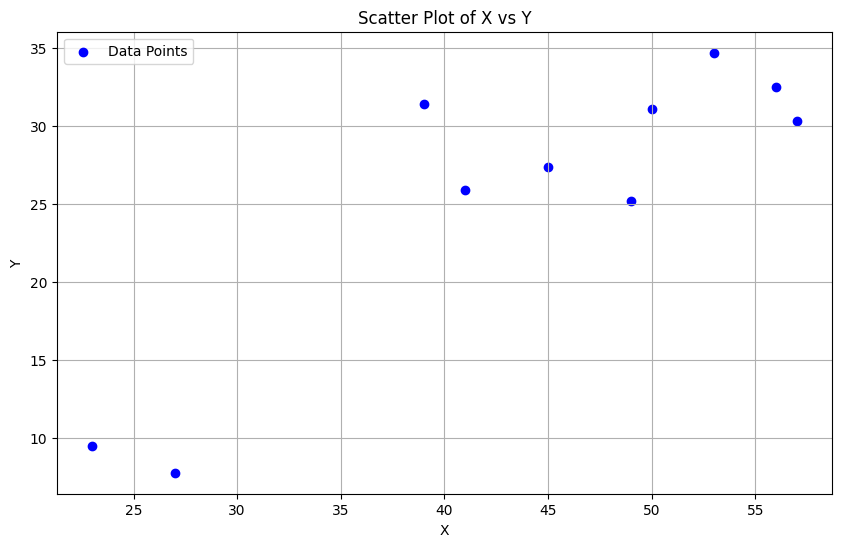

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.title('Scatter Plot of X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

##  Scatter Plot with Regression Line

urpose: Visualize the regression line superimposed on the scatter plot of data points.
Features:
Data points are blue.
Regression line is red.

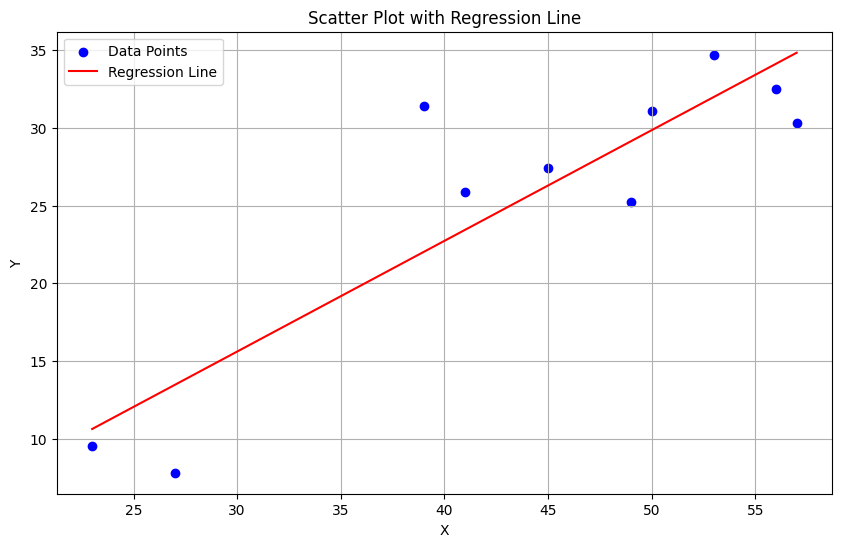

In [19]:
regression_line = [slope * x + intercept for x in X]
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, regression_line, color='red', label='Regression Line')
plt.title('Scatter Plot with Regression Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

## Histogram of X and Y

Purpose: Visualize the distribution of X and Y using histograms.
Features:
X histogram is green.
Y histogram is orange.
Subplots show both distributions side-by-side.

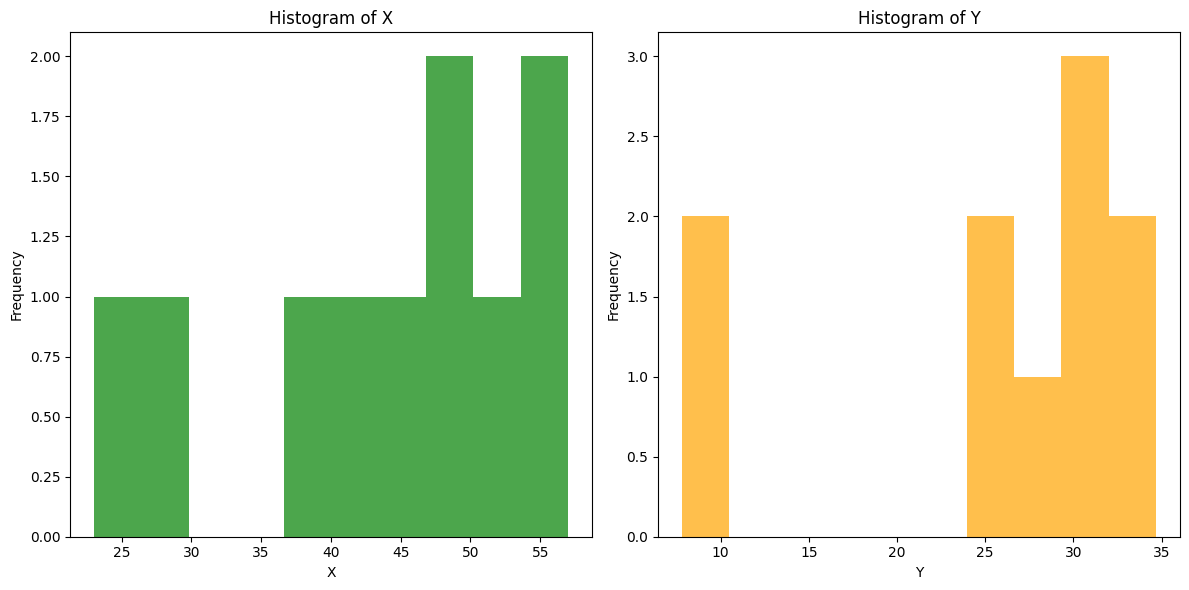

In [20]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(X, bins=10, color='green', alpha=0.7)
plt.title('Histogram of X')
plt.xlabel('X')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(Y, bins=10, color='orange', alpha=0.7)
plt.title('Histogram of Y')
plt.xlabel('Y')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Residual Plot

Purpose: Plot residuals (differences between observed and predicted Y values) to assess the model fit.
Features:
Residuals plotted against X.
Horizontal line at zero for reference.

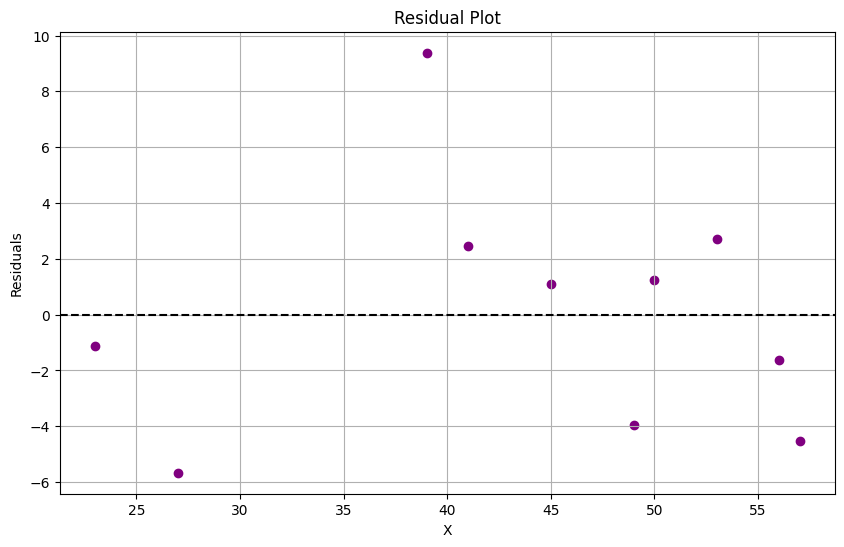

In [21]:
residuals = [y - (slope * x + intercept) for x, y in zip(X, Y)]
plt.figure(figsize=(10, 6))
plt.scatter(X, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('X')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


## Box Plot for X and Y

Purpose: Display the spread and outliers in the data using box plots.
Features:
Separate box plots for X and Y.
Box color and grid improve readability.

C:\Users\Eng. Abdalla\AppData\Local\Temp\ipykernel_10268\73555087.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X, Y], labels=['X', 'Y'], patch_artist=True, boxprops=dict(facecolor='cyan'))


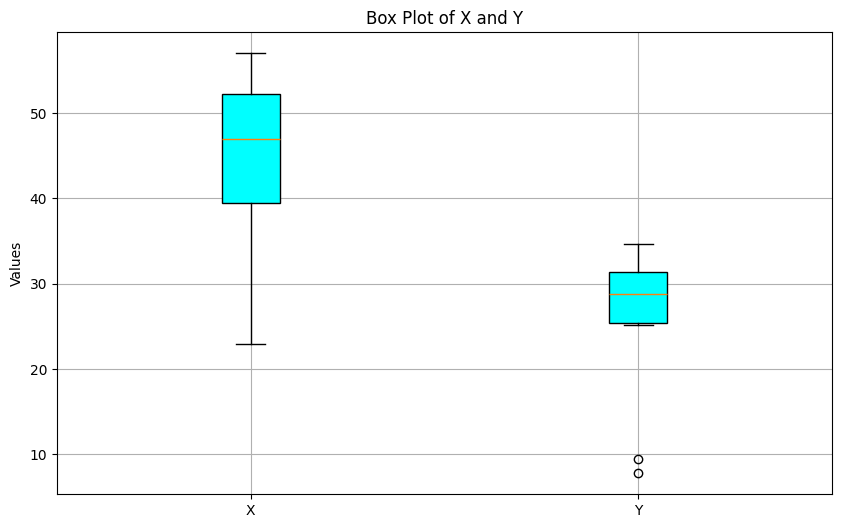

In [22]:
plt.figure(figsize=(10, 6))
plt.boxplot([X, Y], labels=['X', 'Y'], patch_artist=True, boxprops=dict(facecolor='cyan'))
plt.title('Box Plot of X and Y')
plt.ylabel('Values')
plt.grid(True)
plt.show()

## Polynomial Regression (Curve Fitting)

Purpose: Fit a polynomial regression curve of degree 2 to the data.
Features:
Polynomial coefficients computed using np.polyfit.
Curve plotted alongside data points for visualization.

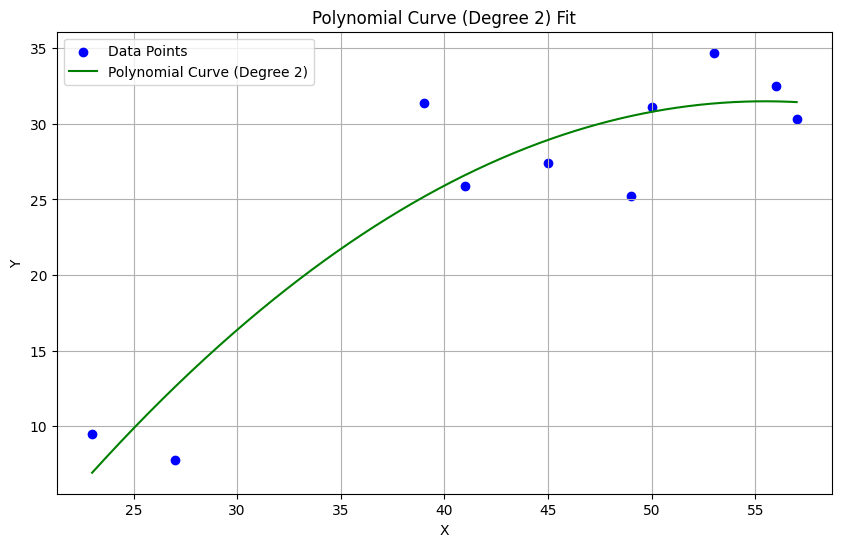

In [23]:
degree = 2  # Degree of the polynomial (adjustable)
polynomial_coefficients = np.polyfit(X, Y, degree)
polynomial = np.poly1d(polynomial_coefficients)
curve = polynomial(np.linspace(min(X), max(X), 500))

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(np.linspace(min(X), max(X), 500), curve, color='green', label=f'Polynomial Curve (Degree {degree})')
plt.title(f'Polynomial Curve (Degree {degree}) Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

## Summary

This script provides a comprehensive statistical analysis pipeline, including descriptive statistics, hypothesis testing, regression, and visualization. Each cell contributes to understanding relationships, trends, and the underlying structure of the data.